# CGAN model to generate new data samples

**Problem statement:** 

> Design a CGAN to generate the new data samples under specific categories as provided from the data set which is a labelled dataset.

**Dataset Description:** 

> Fashion-MNIST dataset is a collection of 6000 greyscale images, with pixel values from 0 to 255. 
> The dimension of each image is 28X28X1.

> We normalize the dataset before processing it to convert the values in the range 0 to 1.

## Model Design

Based on the high-level design as shown in fig 4.1. we use detail design for implementing the CGAN. The detailed design for CGAN to generate the data using the given fashion MNIST data set is as shown in fig 8.1.

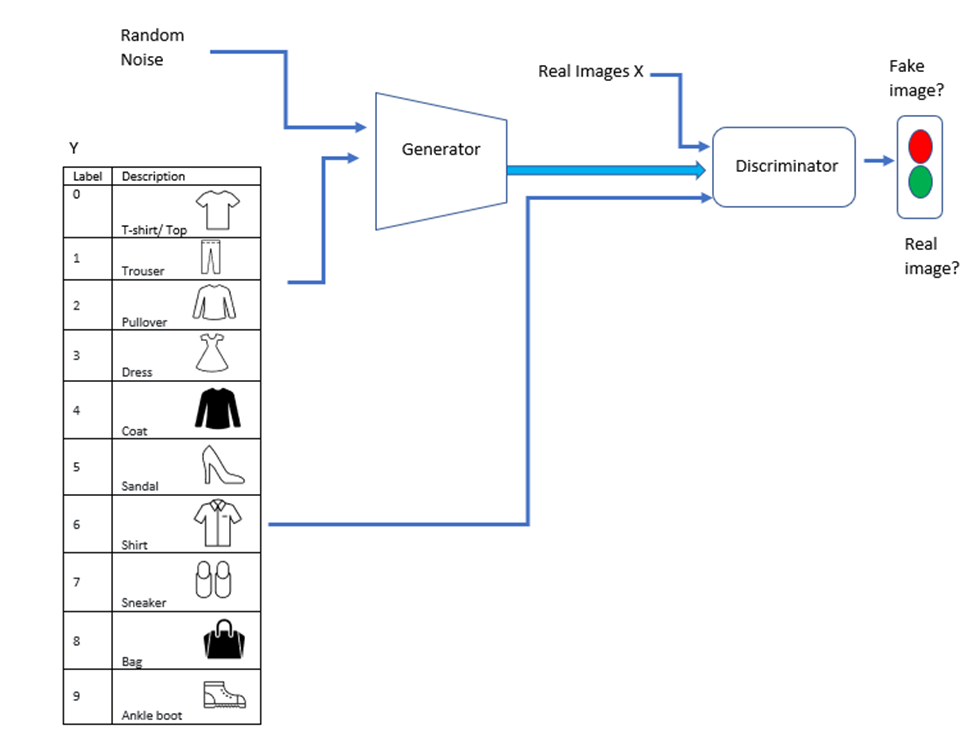

- First, we embed the label into a vector that is 28 x28 x1 pixels in size, or 784.
- In the second step, the embedded label is then reshaped into a tensor that has the same dimensions as the input image (28x28x1).
- In the third step, concatenate the altered label with the associated image, D(x*|y, y). The CGAN Discriminator network is then given this joint representation as input. 

## Installing Packages

In [23]:
%pip install tensorflow numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Importing libraries

In [24]:
import tensorflow as tf
import numpy as np
import math
import matplotlib.pyplot as plt
import os

## Loading & Normalizing Dataset

In [25]:
from tensorflow.keras.utils import to_categorical

# Load the Fashion MNIST dataset
(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images to [0, 1]
x_train = x_train.astype('float32') / 255.0

# Reshape to (num_samples, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_oh = to_categorical(y_train, num_classes=10)

In [26]:
# Step 1: Embed the label into a vector of size 28x28x1 (784)
label_input = tf.keras.layers.Input(shape=(10,))
embedded_label = tf.keras.layers.Dense(28 * 28, activation='linear')(label_input)

# Step 2: Reshape the embedded label to (28, 28, 1)
reshaped_label = tf.keras.layers.Reshape((28, 28, 1))(embedded_label)

# Step 3: Concatenate the reshaped label with the image input
image_input = tf.keras.layers.Input(shape=(28, 28, 1))
concatenated = tf.keras.layers.Concatenate()([image_input, reshaped_label])

## Building a Generator Model

- Concatenate label vector and noise vector. 
- Build a model using layers of BatchNorm-ReLU-Conv2DTranspose to generate fake images. 

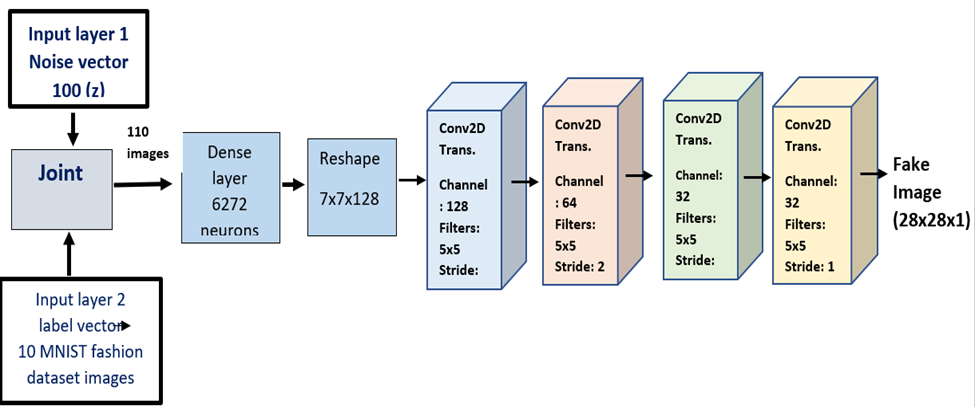

In [27]:
def build_generator(noise_inputs, label_inputs, image_size=28):
    # Concatenate both noise and labels
    x = tf.keras.layers.Concatenate()([noise_inputs, label_inputs])

    # Increase dimensions and resize to 3D to feed it to Conv2DTranspose layer
    x = tf.keras.layers.Dense(7 * 7 * 128)(x)
    x = tf.keras.layers.Reshape((7, 7, 128))(x)

    # First ConvTranspose block
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2DTranspose(128, kernel_size=[5,5], strides=2, padding='same')(x)

    # Second ConvTranspose block
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2DTranspose(64, kernel_size=[5,5], strides=2, padding='same')(x)

    # Third ConvTranspose block
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2DTranspose(32, kernel_size=[5,5], strides=1, padding='same')(x)

    # Output layer: 28x28x1 with sigmoid activation
    x = tf.keras.layers.Conv2DTranspose(1, kernel_size=[5,5], strides=1, padding='same')(x)
    x = tf.keras.layers.Activation('sigmoid')(x)

    # Create the model
    gen_network = tf.keras.models.Model([noise_inputs, label_inputs], x, name='gen_network')
    return gen_network

## Building a Discriminator Model

- Make label inputs of same size as image inputs using dense layer.
- Resize the label vector representation to fit the image's (28,28,1) 3-dimensions.
- Discriminator is implemented as a simple convolution neural network using the LeakyReLU activation function with a slope of 0.2, a 2 stride to down-sample.

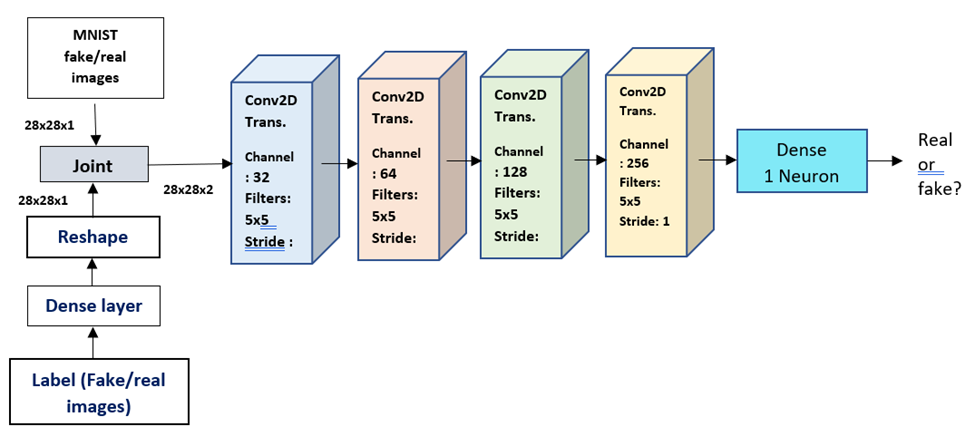

In [28]:
def build_discriminator(image_inputs, label_inputs, image_size=28):
    # Network parameters
    filter_size = 5
    num_filters = [32, 64, 128, 256]
    stride_size = [2, 2, 2, 1]

    # Build the network
    x = image_inputs

    # Make label_inputs of same size as image_inputs for concatenation
    y = tf.keras.layers.Dense(image_size * image_size)(label_inputs)
    y = tf.keras.layers.Reshape((image_size, image_size, 1))(y)
    x = tf.keras.layers.Concatenate()([x, y])

    # First Conv block
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Conv2D(num_filters[0], kernel_size=[filter_size, filter_size], strides=stride_size[0], padding='same')(x)

    # Second Conv block
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Conv2D(num_filters[1], kernel_size=[filter_size, filter_size], strides=stride_size[1], padding='same')(x)

    # Third Conv block
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Conv2D(num_filters[2], kernel_size=[filter_size, filter_size], strides=stride_size[2], padding='same')(x)

    # Fourth Conv block
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Conv2D(num_filters[3], kernel_size=[filter_size, filter_size], strides=stride_size[3], padding='same')(x)

    # Flatten and output
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Create the model
    disc_network = tf.keras.models.Model([image_inputs, label_inputs], x, name='disc_network')
    return disc_network

## Building the models for training

The CGAN Discriminator and Generator models are constructed and assembled, as illustrated in the above figures. Take note that the same input label is fed to both the Generator (to create a sample) and the Discriminator (to make a prediction)

In [29]:
def build_models():
    noise_size = 100
    lr = 2e-4
    decay = 6e-8

    # Build input Layers
    noise_inputs = tf.keras.layers.Input(shape=(noise_size,))
    label_inputs = tf.keras.layers.Input(shape=(10,))
    image_inputs = tf.keras.layers.Input(shape=(28, 28, 1))

    # Build Base Discriminator model
    base_discriminator = build_discriminator(image_inputs, label_inputs)

    # Define discriminator, optimizer and compile model
    discriminator = tf.keras.models.Model(inputs=base_discriminator.inputs,
                                          outputs=base_discriminator.outputs)
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, decay=decay)
    discriminator.compile(loss='binary_crossentropy',
                          optimizer=optimizer,
                          metrics=['accuracy'])

    # Build Generator model
    generator = build_generator(noise_inputs, label_inputs)

    # Build Frozen Discriminator for adversarial model
    frozen_discriminator = tf.keras.models.Model(inputs=base_discriminator.inputs,
                                                 outputs=base_discriminator.outputs)
    frozen_discriminator.trainable = False

    # Build Adversarial model (generator + frozen discriminator)
    optimizer_adv = tf.keras.optimizers.RMSprop(learning_rate=lr * 0.5, decay=decay * 0.5)
    adversarial = tf.keras.models.Model([noise_inputs, label_inputs],
                                        frozen_discriminator([generator.output, label_inputs]))
    adversarial.compile(loss='binary_crossentropy',
                        optimizer=optimizer_adv,
                        metrics=['accuracy'])

    return generator, discriminator, adversarial

## Calling Models

In [30]:
G, D, A = build_models()
G.summary()
D.summary()

Model: "gen_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 110)       │          0 │ input_layer_13[0… │
│ (Concatenate)       │                   │            │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 6272)      │    696,192 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 7, 7, 128) │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ reshape_8[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 14, 14,    │    409,728 │ activation_4[0][… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 28, 28,    │    204,864 │ activation_5[0][… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 28, 28,    │     51,232 │ activation_6[0][… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 28, 28, 1) │        801 │ conv2d_transpose… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 28, 28, 1) │          0 │ conv2d_transpose… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,364,097 (5.20 MB)

 Trainable params: 1,363,457 (5.20 MB)

 Non-trainable params: 640 (2.50 KB)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 784)       │      8,624 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 28, 28, 2) │          0 │ input_layer_15[0… │
│ (Concatenate)       │                   │            │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 28, 28, 2) │          0 │ concatenate_7[0]… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │      1,632 │ leaky_re_lu_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 64)  │     51,264 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 7, 7, 64)  │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 4, 4, 128) │    204,928 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 4, 4, 128) │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 4, 4, 256) │    819,456 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4096)      │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │      4,097 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,090,001 (4.16 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,090,001 (4.16 MB)

## Training Model

In [33]:
def train_cgan(G, D, A, x_train, y_train_oh, noise_size=100, epochs=10000, batch_size=64, print_every=1000):
	for epoch in range(1, epochs + 1):
		# 1. Sample a batch of real images and labels
		idx = np.random.randint(0, x_train.shape[0], batch_size)
		real_images = x_train[idx]
		real_labels = y_train_oh[idx]

		# 2. Generate a batch of fake images and labels
		noise = np.random.normal(0, 1, (batch_size, noise_size))
		fake_labels = np.eye(10)[np.random.choice(10, batch_size)]
		fake_images = G.predict([noise, fake_labels], verbose=0)

		# 3. Prepare targets for real and fake images
		real_targets = np.ones((batch_size, 1))
		fake_targets = np.zeros((batch_size, 1))

		# 4. Train discriminator on real and fake
		d_loss_real = D.train_on_batch([real_images, real_labels], real_targets)
		d_loss_fake = D.train_on_batch([fake_images, fake_labels], fake_targets)

		# 5. Train generator (via adversarial model)
		g_loss = A.train_on_batch([noise, fake_labels], real_targets)

		# Print progress
		if epoch % print_every == 0 or epoch == 1:
			print(f"Epoch {epoch}/{epochs} | D loss: {0.5 * (d_loss_real[0] + d_loss_fake[0]):.4f} | G loss: {g_loss[0]:.4f}")

train_cgan(G, D, A, x_train, y_train_oh, noise_size=100, epochs=10000, batch_size=64)

2025-06-13 20:29:17.633411: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 27596800 exceeds 10% of free system memory.


Epoch 1/10000 | D loss: 0.6923 | G loss: 0.6869


2025-06-13 20:29:18.744407: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 27596800 exceeds 10% of free system memory.
2025-06-13 20:29:19.822844: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 27596800 exceeds 10% of free system memory.
2025-06-13 20:29:21.117485: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 27596800 exceeds 10% of free system memory.


KeyboardInterrupt: 

## Visualize Generated Images

In [ ]:
def plot_cgan_generated_images(generator, noise_size=100, num_classes=10):
	# Generate one image per class
	noise = np.random.normal(0, 1, (num_classes, noise_size))
	labels = np.eye(num_classes)
	gen_images = generator.predict([noise, labels], verbose=0)

	plt.figure(figsize=(12, 2))
	for i in range(num_classes):
		plt.subplot(1, num_classes, i + 1)
		plt.imshow(gen_images[i, :, :, 0], cmap='gray')
		plt.axis('off')
		plt.title(f"Class {i}")
	plt.tight_layout()
	plt.show()

plot_cgan_generated_images(G, noise_size=100, num_classes=10)

## Output Layer

At the output layer, sigmoid activation function is used to produce a probability that the input image-label pair is real or fake.

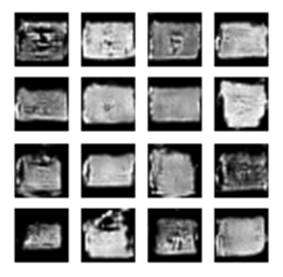